# 04 — Baseline Anomaly Detection

## Objective

The goal of this notebook is to detect baseline sales anomalies using statistical rules and business-friendly thresholds.

This notebook focuses on identifying:

- transaction volume spikes,
- transaction volume drops,
- paid revenue spikes,
- paid revenue drops,
- combined anomaly candidates,
- and outlet-level abnormal days.

The approach is unsupervised because the dataset does not contain confirmed anomaly labels.

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 120)

# Load scored feature dataset
features = pd.read_csv("../data/processed/daily_outlet_features_scored.csv")

# Convert date column
features["date"] = pd.to_datetime(features["date"])

print("Features shape:", features.shape)

features.head()


Features shape: (807, 26)


,date,outlet,transaction_count,total_revenue,avg_transaction_value,total_items,avg_basket_size,zero_value_transactions,day_name,day_of_week,is_weekend,month,tx_lag_1,rev_lag_1_x,tx_roll_mean_7,tx_roll_std_7,tx_diff_from_roll7,tx_zscore_roll7,tx_pct_change_1d,paid_revenue,rev_lag_1_y,rev_roll_mean_7,rev_roll_std_7,rev_diff_from_roll7,rev_zscore_roll7,rev_pct_change_1d
0,2025-01-05,SHOP001,90,2114000,23488.888889,106,1.177778,3,Sunday,6,1,1,99.0,2473000.0,94.000000,10.440307,-4.000000,-0.383130,-0.090909,2114000,2473000.0,2.357000e+06,308797.668385,-243000.000000,-0.786923,-0.145168
1,2025-01-06,SHOP001,82,1885000,22987.804878,90,1.097561,2,Monday,0,0,1,90.0,2114000.0,93.000000,8.755950,-11.000000,-1.256288,-0.088889,1885000,2114000.0,2.296250e+06,279880.182697,-411250.000000,-1.469379,-0.108325
2,2025-01-07,SHOP001,96,2472000,25750.000000,111,1.156250,1,Tuesday,1,0,1,82.0,1885000.0,90.800000,9.038805,5.200000,0.575297,0.170732,2472000,1885000.0,2.214000e+06,304261.400772,258000.000000,0.847955,0.311406
3,2025-01-08,SHOP001,110,2646000,24054.545455,125,1.136364,1,Wednesday,2,0,1,96.0,2472000.0,91.666667,8.358628,18.333333,2.193342,0.145833,2646000,2472000.0,2.257000e+06,291811.583046,389000.000000,1.333052,0.070388
4,2025-01-09,SHOP001,72,1959000,27208.333333,85,1.180556,1,Thursday,3,0,1,110.0,2646000.0,94.285714,10.307187,-22.285714,-2.162153,-0.345455,1959000,2646000.0,2.312571e+06,304267.895745,-353571.428571,-1.162040,-0.259637


In [3]:
key_cols = [
    "date",
    "outlet",
    "transaction_count",
    "paid_revenue",
    "tx_zscore_roll7",
    "rev_zscore_roll7",
    "tx_pct_change_1d",
    "rev_pct_change_1d"
]

features[key_cols].isna().sum()

date                 0
outlet               0
transaction_count    0
paid_revenue         0
tx_zscore_roll7      0
rev_zscore_roll7     0
tx_pct_change_1d     0
rev_pct_change_1d    0
dtype: int64

In [4]:
features.shape
features[key_cols].isna().sum()
features[[
    "date",
    "outlet",
    "transaction_count",
    "paid_revenue",
    "tx_zscore_roll7",
    "rev_zscore_roll7"
]].head()

,date,outlet,transaction_count,paid_revenue,tx_zscore_roll7,rev_zscore_roll7
0,2025-01-05,SHOP001,90,2114000,-0.383130,-0.786923
1,2025-01-06,SHOP001,82,1885000,-1.256288,-1.469379
2,2025-01-07,SHOP001,96,2472000,0.575297,0.847955
3,2025-01-08,SHOP001,110,2646000,2.193342,1.333052
4,2025-01-09,SHOP001,72,1959000,-2.162153,-1.162040


## Step 1 Findings — Loaded Scored Feature Dataset

The scored daily outlet-level feature dataset was loaded successfully.

Each row represents one outlet on one date.

The dataset contains engineered anomaly detection signals such as:

- transaction count rolling z-score,
- paid revenue rolling z-score,
- transaction count percentage change,
- paid revenue percentage change.

This dataset is ready for baseline anomaly detection because rows without enough rolling history were already removed during feature engineering.

## Step 2 — Define Baseline Anomaly Rules

### What we are doing

In this step, we define baseline anomaly rules using rolling z-score features.

The goal is to flag outlet-days where transaction volume or paid revenue is unusually high or unusually low compared to recent outlet-specific history.

### Why we are doing this

The dataset does not contain confirmed anomaly labels, so we use unsupervised statistical rules as a first baseline.

Rolling z-scores are used because they compare each outlet-day against the recent historical behavior of the same outlet.

### Threshold selection

A z-score threshold of 2.0 is used as the initial exploratory threshold.

This means that an outlet-day is flagged if its transaction count or paid revenue is more than 2 rolling standard deviations above or below its recent baseline.

This threshold is intentionally moderate so that we can inspect enough candidate anomalies during the first baseline analysis.

In [5]:
# Define baseline z-score threshold
z_threshold = 2.0

# Transaction volume anomaly flags
features["tx_spike_flag"] = (
    features["tx_zscore_roll7"] >= z_threshold
).astype(int)

features["tx_drop_flag"] = (
    features["tx_zscore_roll7"] <= -z_threshold
).astype(int)

# Paid revenue anomaly flags
features["rev_spike_flag"] = (
    features["rev_zscore_roll7"] >= z_threshold
).astype(int)

features["rev_drop_flag"] = (
    features["rev_zscore_roll7"] <= -z_threshold
).astype(int)

# Combined baseline anomaly flag
features["baseline_anomaly_flag"] = (
    (features["tx_spike_flag"] == 1) |
    (features["tx_drop_flag"] == 1) |
    (features["rev_spike_flag"] == 1) |
    (features["rev_drop_flag"] == 1)
).astype(int)

features[[
    "date",
    "outlet",
    "transaction_count",
    "paid_revenue",
    "tx_zscore_roll7",
    "rev_zscore_roll7",
    "tx_spike_flag",
    "tx_drop_flag",
    "rev_spike_flag",
    "rev_drop_flag",
    "baseline_anomaly_flag"
]].head()

,date,outlet,transaction_count,paid_revenue,tx_zscore_roll7,rev_zscore_roll7,tx_spike_flag,tx_drop_flag,rev_spike_flag,rev_drop_flag,baseline_anomaly_flag
0,2025-01-05,SHOP001,90,2114000,-0.383130,-0.786923,0,0,0,0,0
1,2025-01-06,SHOP001,82,1885000,-1.256288,-1.469379,0,0,0,0,0
2,2025-01-07,SHOP001,96,2472000,0.575297,0.847955,0,0,0,0,0
3,2025-01-08,SHOP001,110,2646000,2.193342,1.333052,1,0,0,0,1
4,2025-01-09,SHOP001,72,1959000,-2.162153,-1.162040,0,1,0,0,1


In [6]:
anomaly_counts = {
    "transaction_spikes": features["tx_spike_flag"].sum(),
    "transaction_drops": features["tx_drop_flag"].sum(),
    "revenue_spikes": features["rev_spike_flag"].sum(),
    "revenue_drops": features["rev_drop_flag"].sum(),
    "total_baseline_anomalies": features["baseline_anomaly_flag"].sum()
}

anomaly_counts

{'transaction_spikes': np.int64(49),
 'transaction_drops': np.int64(44),
 'revenue_spikes': np.int64(48),
 'revenue_drops': np.int64(38),
 'total_baseline_anomalies': np.int64(121)}

In [7]:
baseline_anomalies = features[
    features["baseline_anomaly_flag"] == 1
].copy()

print("Baseline anomaly rows:", len(baseline_anomalies))

baseline_anomalies[[
    "date",
    "outlet",
    "transaction_count",
    "paid_revenue",
    "tx_zscore_roll7",
    "rev_zscore_roll7",
    "tx_spike_flag",
    "tx_drop_flag",
    "rev_spike_flag",
    "rev_drop_flag"
]].head(10)

Baseline anomaly rows: 121


,date,outlet,transaction_count,paid_revenue,tx_zscore_roll7,rev_zscore_roll7,tx_spike_flag,tx_drop_flag,rev_spike_flag,rev_drop_flag
3,2025-01-08,SHOP001,110,2646000,2.193342,1.333052,1,0,0,0
4,2025-01-09,SHOP001,72,1959000,-2.162153,-1.162040,0,1,0,0
12,2025-01-17,SHOP001,70,1783000,-2.259467,-1.902924,0,1,0,0
18,2025-01-23,SHOP001,103,2469000,2.276626,1.956113,1,0,0,0
22,2025-01-27,SHOP001,74,1766000,-1.817112,-3.161708,0,0,0,1
27,2025-02-01,SHOP001,111,2762000,3.365584,3.831914,1,0,1,0
35,2025-02-09,SHOP001,118,3068000,3.697893,2.653879,1,0,1,0
43,2025-02-17,SHOP001,118,3139000,1.966300,2.732115,0,0,1,0
44,2025-02-18,SHOP001,119,2862000,2.005068,1.030579,1,0,0,0
47,2025-02-21,SHOP001,83,2045000,-2.045779,-1.567834,0,1,0,0


In [8]:
anomaly_counts = {
    "transaction_spikes": features["tx_spike_flag"].sum(),
    "transaction_drops": features["tx_drop_flag"].sum(),
    "revenue_spikes": features["rev_spike_flag"].sum(),
    "revenue_drops": features["rev_drop_flag"].sum(),
    "total_baseline_anomalies": features["baseline_anomaly_flag"].sum(),
    "total_rows": len(features),
    "anomaly_rate_percent": round(features["baseline_anomaly_flag"].mean() * 100, 2)
}

anomaly_counts


{'transaction_spikes': np.int64(49),
 'transaction_drops': np.int64(44),
 'revenue_spikes': np.int64(48),
 'revenue_drops': np.int64(38),
 'total_baseline_anomalies': np.int64(121),
 'total_rows': 807,
 'anomaly_rate_percent': np.float64(14.99)}

## Step 3 — Threshold Sensitivity Check

### What we are doing

In this step, we compare baseline anomaly counts using different rolling z-score thresholds.

The initial threshold of 2.0 flagged about 15% of outlet-day rows as anomalies.

To understand whether this threshold is too sensitive, we compare it with stricter thresholds.

### Why we are doing this

In unsupervised anomaly detection, there are no confirmed anomaly labels.

Therefore, threshold selection requires a balance between:

- catching meaningful anomaly candidates,
- avoiding too many false positives,
- and keeping the number of flagged records practical for business review.

### Thresholds compared

The following thresholds are tested:

- 2.0
- 2.5
- 3.0

In [9]:
thresholds = [2.0, 2.5, 3.0]

threshold_results = []

for threshold in thresholds:
    tx_spike = features["tx_zscore_roll7"] >= threshold
    tx_drop = features["tx_zscore_roll7"] <= -threshold
    rev_spike = features["rev_zscore_roll7"] >= threshold
    rev_drop = features["rev_zscore_roll7"] <= -threshold
    
    any_anomaly = tx_spike | tx_drop | rev_spike | rev_drop
    
    threshold_results.append({
        "threshold": threshold,
        "transaction_spikes": tx_spike.sum(),
        "transaction_drops": tx_drop.sum(),
        "revenue_spikes": rev_spike.sum(),
        "revenue_drops": rev_drop.sum(),
        "total_anomaly_rows": any_anomaly.sum(),
        "anomaly_rate_percent": round(any_anomaly.mean() * 100, 2)
    })

threshold_results_df = pd.DataFrame(threshold_results)

threshold_results_df


,threshold,transaction_spikes,transaction_drops,revenue_spikes,revenue_drops,total_anomaly_rows,anomaly_rate_percent
0,2.0,49,44,48,38,121,14.99
1,2.5,29,15,29,21,62,7.68
2,3.0,16,8,18,8,35,4.34


## Findings — Threshold Sensitivity Check

A threshold sensitivity check was performed using rolling z-score thresholds of 2.0, 2.5, and 3.0.

### Results

- Threshold 2.0 flagged 121 anomaly rows, representing approximately 15.0% of the scored dataset.
- Threshold 2.5 flagged 62 anomaly rows, representing approximately 7.7% of the scored dataset.
- Threshold 3.0 flagged 35 anomaly rows, representing approximately 4.3% of the scored dataset.

### Interpretation

The 2.0 threshold is useful for exploratory analysis but may be too sensitive because it flags a relatively large portion of the dataset.

The 3.0 threshold is more conservative and highlights stronger anomalies, but it may miss meaningful business events.

The 2.5 threshold provides a balanced middle ground between sensitivity and practicality.

### Decision

The baseline anomaly detection threshold will be set to:

`z_threshold = 2.5`

This threshold will be used for the next stage of anomaly inspection and business interpretation.
``

In [10]:
# Final selected threshold
z_threshold = 2.5

# Transaction volume anomaly flags
features["tx_spike_flag"] = (
    features["tx_zscore_roll7"] >= z_threshold
).astype(int)

features["tx_drop_flag"] = (
    features["tx_zscore_roll7"] <= -z_threshold
).astype(int)

# Paid revenue anomaly flags
features["rev_spike_flag"] = (
    features["rev_zscore_roll7"] >= z_threshold
).astype(int)

features["rev_drop_flag"] = (
    features["rev_zscore_roll7"] <= -z_threshold
).astype(int)

# Combined baseline anomaly flag
features["baseline_anomaly_flag"] = (
    (features["tx_spike_flag"] == 1) |
    (features["tx_drop_flag"] == 1) |
    (features["rev_spike_flag"] == 1) |
    (features["rev_drop_flag"] == 1)
).astype(int)

# Create final anomaly subset
baseline_anomalies = features[
    features["baseline_anomaly_flag"] == 1
].copy()

print("Final baseline anomalies:", len(baseline_anomalies))
print("Final anomaly rate:", round(features["baseline_anomaly_flag"].mean() * 100, 2), "%")

Final baseline anomalies: 62
Final anomaly rate: 7.68 %


In [11]:
baseline_anomalies[[
    "date",
    "outlet",
    "transaction_count",
    "paid_revenue",
    "tx_zscore_roll7",
    "rev_zscore_roll7",
    "tx_spike_flag",
    "tx_drop_flag",
    "rev_spike_flag",
    "rev_drop_flag"
]].head(10)

,date,outlet,transaction_count,paid_revenue,tx_zscore_roll7,rev_zscore_roll7,tx_spike_flag,tx_drop_flag,rev_spike_flag,rev_drop_flag
22,2025-01-27,SHOP001,74,1766000,-1.817112,-3.161708,0,0,0,1
27,2025-02-01,SHOP001,111,2762000,3.365584,3.831914,1,0,1,0
35,2025-02-09,SHOP001,118,3068000,3.697893,2.653879,1,0,1,0
43,2025-02-17,SHOP001,118,3139000,1.966300,2.732115,0,0,1,0
55,2025-03-01,SHOP001,76,1798000,-4.155487,-3.329133,0,1,0,1
69,2025-03-15,SHOP001,94,2065000,-0.530560,-2.503257,0,0,0,1
70,2025-03-16,SHOP001,82,2077000,-3.623744,-1.722364,0,1,0,0
76,2025-03-22,SHOP001,76,1695000,-2.002270,-2.842740,0,0,0,1
95,2025-04-10,SHOP001,113,3146000,2.385139,3.995036,0,0,1,0
106,2025-04-21,SHOP001,73,1887000,-3.784899,-3.677238,0,1,0,1


## Findings — Final Baseline Anomaly Examples

Using a final rolling z-score threshold of 2.5, the baseline anomaly rules identified several types of anomaly candidates.

### Revenue-only anomalies

Some rows were flagged because paid revenue was unusually high or low, even when transaction count did not cross the anomaly threshold.

These cases may indicate changes in customer spending behavior or product mix.

### Transaction-only anomalies

Some rows were flagged because transaction volume was unusually high or low, even when paid revenue did not cross the threshold.

These cases may indicate unusual customer traffic patterns.

### Combined anomalies

Some rows were flagged by both transaction volume and paid revenue.

These are stronger anomaly candidates because both customer activity and business impact were unusual on the same outlet-day.

### Interpretation

The baseline anomaly rules are producing meaningful and interpretable anomaly candidates.

The results confirm that transaction count and paid revenue provide complementary signals for anomaly detection.

In [12]:
baseline_anomalies["outlet"].value_counts()

outlet
SHOP003    24
SHOP001    20
SHOP002    18
Name: count, dtype: int64

In [13]:
baseline_anomalies["outlet"].value_counts(normalize=True).round(3) * 100

outlet
SHOP003    38.7
SHOP001    32.3
SHOP002    29.0
Name: proportion, dtype: float64

In [14]:
outlet_anomaly_summary = (
    features
    .groupby("outlet")
    .agg(
        total_days=("baseline_anomaly_flag", "count"),
        anomaly_days=("baseline_anomaly_flag", "sum")
    )
    .reset_index()
)

outlet_anomaly_summary["anomaly_rate_percent"] = (
    outlet_anomaly_summary["anomaly_days"] /
    outlet_anomaly_summary["total_days"] * 100
).round(2)

outlet_anomaly_summary

,outlet,total_days,anomaly_days,anomaly_rate_percent
0,SHOP001,269,20,7.43
1,SHOP002,269,18,6.69
2,SHOP003,269,24,8.92


In [15]:
monthly_anomaly_summary = (
    features
    .groupby("month")
    .agg(
        total_outlet_days=("baseline_anomaly_flag", "count"),
        anomaly_days=("baseline_anomaly_flag", "sum")
    )
    .reset_index()
)

monthly_anomaly_summary["anomaly_rate_percent"] = (
    monthly_anomaly_summary["anomaly_days"] /
    monthly_anomaly_summary["total_outlet_days"] * 100
).round(2)

monthly_anomaly_summary

,month,total_outlet_days,anomaly_days,anomaly_rate_percent
0,1,81,4,4.94
1,2,84,8,9.52
2,3,93,10,10.75
3,4,90,6,6.67
4,5,93,8,8.60
5,6,90,7,7.78
6,7,93,6,6.45
7,8,93,6,6.45
8,9,90,7,7.78


In [17]:
final_anomaly_counts = {
    "transaction_spikes": features["tx_spike_flag"].sum(),
    "transaction_drops": features["tx_drop_flag"].sum(),
    "revenue_spikes": features["rev_spike_flag"].sum(),
    "revenue_drops": features["rev_drop_flag"].sum(),
    "total_baseline_anomalies": features["baseline_anomaly_flag"].sum(),
    "anomaly_rate_percent": round(features["baseline_anomaly_flag"].mean() * 100, 2)
}

final_anomaly_counts


{'transaction_spikes': np.int64(29),
 'transaction_drops': np.int64(15),
 'revenue_spikes': np.int64(29),
 'revenue_drops': np.int64(21),
 'total_baseline_anomalies': np.int64(62),
 'anomaly_rate_percent': np.float64(7.68)}

## Findings — Anomaly Distribution by Outlet and Month

### Outlet-level anomaly distribution

The final baseline anomaly threshold of 2.5 produced relatively balanced anomaly rates across the three outlets.

- SHOP001 had an anomaly rate of 7.43%.
- SHOP002 had an anomaly rate of 6.69%.
- SHOP003 had an anomaly rate of 8.92%.

SHOP003 had the highest anomaly rate, but the difference was not extreme.

This suggests that the outlet-specific rolling baseline approach is working reasonably well and is not heavily biased toward one outlet.

### Month-level anomaly distribution

Monthly anomaly rates ranged from approximately 4.94% to 10.75%.

March had the highest anomaly rate at 10.75%, followed by February at 9.52% and May at 8.60%.

January had the lowest anomaly rate at 4.94%.

The anomalies were not concentrated only in June or July, even though those months showed higher transaction activity during exploratory analysis.

This suggests that the rolling baseline adapted to broader demand shifts and focused more on local deviations from recent behavior.

### Final anomaly type counts

Using a z-score threshold of 2.5:

- 29 transaction volume spikes were detected.
- 15 transaction volume drops were detected.
- 29 revenue spikes were detected.
- 21 revenue drops were detected.
- 62 total outlet-day rows were flagged as baseline anomalies.

The final anomaly rate was approximately 7.68%.

### Interpretation

The baseline anomaly rules produced a manageable set of candidate anomalies.

The detected anomalies include transaction-driven anomalies, revenue-driven anomalies, and combined anomalies where both transaction volume and revenue were unusual.

These results are suitable for further inspection and business interpretation.
``

In [18]:
features["max_abs_zscore"] = features[
    ["tx_zscore_roll7", "rev_zscore_roll7"]
].abs().max(axis=1)

baseline_anomalies = features[
    features["baseline_anomaly_flag"] == 1
].copy()

baseline_anomalies = baseline_anomalies.sort_values(
    "max_abs_zscore",
    ascending=False
)

baseline_anomalies[[
    "date",
    "outlet",
    "transaction_count",
    "paid_revenue",
    "tx_zscore_roll7",
    "rev_zscore_roll7",
    "tx_spike_flag",
    "tx_drop_flag",
    "rev_spike_flag",
    "rev_drop_flag",
    "max_abs_zscore"
]].head(15)

,date,outlet,transaction_count,paid_revenue,tx_zscore_roll7,rev_zscore_roll7,tx_spike_flag,tx_drop_flag,rev_spike_flag,rev_drop_flag,max_abs_zscore
147,2025-06-01,SHOP001,138,3185000,12.622943,7.645257,1,0,1,0,12.622943
654,2025-05-01,SHOP003,55,1477000,6.832124,8.084986,1,0,1,0,8.084986
624,2025-04-01,SHOP003,25,537000,-6.271246,-6.065374,0,1,0,1,6.271246
372,2025-04-18,SHOP002,43,1096000,4.249999,4.904342,1,0,1,0,4.904342
262,2025-09-24,SHOP001,108,2649000,4.865308,4.009434,1,0,1,0,4.865308
355,2025-04-01,SHOP002,22,437000,-2.681291,-4.261753,0,1,0,1,4.261753
672,2025-05-19,SHOP003,75,1844000,4.205259,4.162454,1,0,1,0,4.205259
55,2025-03-01,SHOP001,76,1798000,-4.155487,-3.329133,0,1,0,1,4.155487
405,2025-05-21,SHOP002,45,1128000,2.908374,4.023078,1,0,1,0,4.023078
95,2025-04-10,SHOP001,113,3146000,2.385139,3.995036,0,0,1,0,3.995036


In [19]:
def classify_anomaly(row):
    if row["tx_spike_flag"] == 1 and row["rev_spike_flag"] == 1:
        return "Transaction and revenue spike"
    elif row["tx_drop_flag"] == 1 and row["rev_drop_flag"] == 1:
        return "Transaction and revenue drop"
    elif row["tx_spike_flag"] == 1:
        return "Transaction spike"
    elif row["tx_drop_flag"] == 1:
        return "Transaction drop"
    elif row["rev_spike_flag"] == 1:
        return "Revenue spike"
    elif row["rev_drop_flag"] == 1:
        return "Revenue drop"
    else:
        return "Other"

features["anomaly_type"] = features.apply(classify_anomaly, axis=1)

baseline_anomalies = features[
    features["baseline_anomaly_flag"] == 1
].copy()

baseline_anomalies = baseline_anomalies.sort_values(
    "max_abs_zscore",
    ascending=False
)

baseline_anomalies[[
    "date",
    "outlet",
    "transaction_count",
    "paid_revenue",
    "tx_zscore_roll7",
    "rev_zscore_roll7",
    "max_abs_zscore",
    "anomaly_type"
]].head(15)

,date,outlet,transaction_count,paid_revenue,tx_zscore_roll7,rev_zscore_roll7,max_abs_zscore,anomaly_type
147,2025-06-01,SHOP001,138,3185000,12.622943,7.645257,12.622943,Transaction and revenue spike
654,2025-05-01,SHOP003,55,1477000,6.832124,8.084986,8.084986,Transaction and revenue spike
624,2025-04-01,SHOP003,25,537000,-6.271246,-6.065374,6.271246,Transaction and revenue drop
372,2025-04-18,SHOP002,43,1096000,4.249999,4.904342,4.904342,Transaction and revenue spike
262,2025-09-24,SHOP001,108,2649000,4.865308,4.009434,4.865308,Transaction and revenue spike
355,2025-04-01,SHOP002,22,437000,-2.681291,-4.261753,4.261753,Transaction and revenue drop
672,2025-05-19,SHOP003,75,1844000,4.205259,4.162454,4.205259,Transaction and revenue spike
55,2025-03-01,SHOP001,76,1798000,-4.155487,-3.329133,4.155487,Transaction and revenue drop
405,2025-05-21,SHOP002,45,1128000,2.908374,4.023078,4.023078,Transaction and revenue spike
95,2025-04-10,SHOP001,113,3146000,2.385139,3.995036,3.995036,Revenue spike


## Findings — Strongest Baseline Anomalies

The strongest baseline anomalies were ranked using the maximum absolute z-score across transaction volume and paid revenue.

### Key observations

The strongest anomaly was observed on 2025-06-01 for SHOP001, where both transaction volume and paid revenue showed extreme positive deviations from the recent rolling baseline.

This appears to represent the beginning of a major high-demand period or business shift.

April 1 was also highlighted as an important anomaly date, with both SHOP002 and SHOP003 showing strong transaction and revenue drops.

This suggests that April 1 may represent a broader business event, operational disruption, holiday effect, or data-related issue affecting multiple outlets.

### Anomaly types observed

The strongest anomalies included:

- transaction and revenue spikes,
- transaction and revenue drops,
- revenue-only spikes.

Combined transaction and revenue anomalies are stronger candidates because both customer activity and business impact changed unusually on the same outlet-day.

Revenue-only anomalies may indicate changes in customer spending behavior, basket value, or product mix.

### Interpretation

The baseline anomaly detection results are interpretable and business-relevant.

The rolling z-score approach successfully identifies local deviations from recent outlet-specific behavior rather than simply flagging globally high or low months.

In [20]:
anomaly_dates_summary = (
    baseline_anomalies
    .groupby("date")
    .agg(
        anomalous_outlets=("outlet", "nunique"),
        anomaly_rows=("outlet", "count"),
        outlets=("outlet", lambda x: ", ".join(sorted(x.unique())))
    )
    .reset_index()
    .sort_values(["anomalous_outlets", "anomaly_rows"], ascending=False)
)

anomaly_dates_summary.head(15)

,date,anomalous_outlets,anomaly_rows,outlets
4,2025-02-01,2,2,"SHOP001, SHOP003"
16,2025-03-16,2,2,"SHOP001, SHOP003"
20,2025-04-01,2,2,"SHOP002, SHOP003"
23,2025-04-21,2,2,"SHOP001, SHOP003"
32,2025-06-01,2,2,"SHOP001, SHOP003"
40,2025-07-11,2,2,"SHOP002, SHOP003"
41,2025-07-25,2,2,"SHOP002, SHOP003"
49,2025-09-06,2,2,"SHOP002, SHOP003"
0,2025-01-21,1,1,SHOP003
1,2025-01-25,1,1,SHOP002


## Findings — Repeated Anomaly Dates

The anomaly dates were grouped to identify whether multiple outlets were anomalous on the same date.

### Key observations

Several dates had two anomalous outlets on the same day.

Examples include:

- 2025-02-01
- 2025-03-16
- 2025-04-01
- 2025-04-21
- 2025-06-01
- 2025-07-11
- 2025-07-25
- 2025-09-06

No date had all three outlets flagged as anomalous.

### Business interpretation

Dates where multiple outlets are anomalous may indicate broader business or contextual events rather than isolated outlet-specific issues.

For example, 2025-04-01 was flagged for both SHOP002 and SHOP003 and appears to represent a multi-outlet drop.

2025-06-01 was flagged for both SHOP001 and SHOP003 and appears to represent the beginning of a strong demand increase.

### Implications

Repeated anomaly dates should receive higher priority during business review because they may represent broader business events, calendar effects, operational changes, or data-related issues.


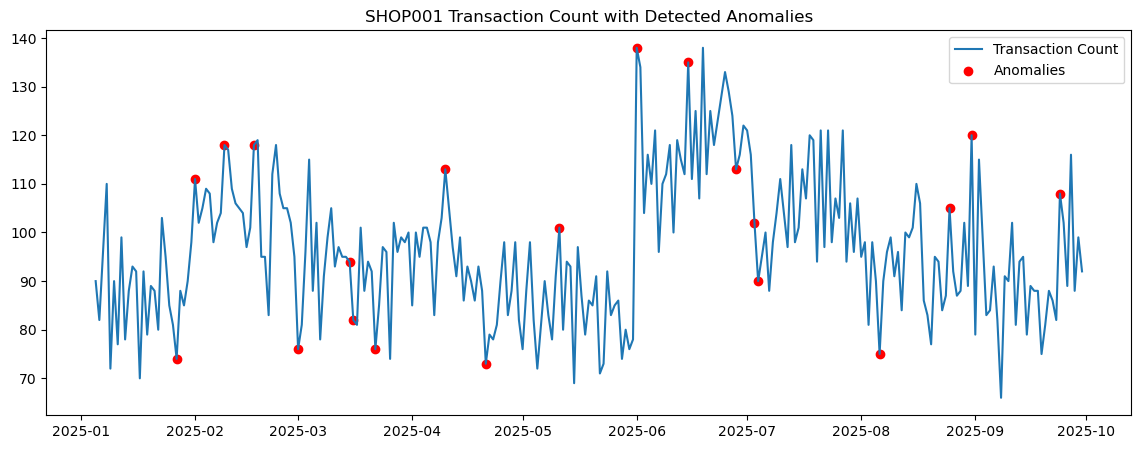

In [ ]:
plt.figure(figsize=(14,5))

shop1 = features[features["outlet"] == "SHOP002"]
plt.plot(shop1["date"], shop1["transaction_count"], label="Transaction Count")

anomalies_shop1 = shop1[shop1["baseline_anomaly_flag"] == 1]

plt.scatter(
    anomalies_shop1["date"],
    anomalies_shop1["transaction_count"],
    color="red",
    label="Anomalies"
)

plt.title("SHOP001 Transaction Count with Detected Anomalies")
plt.legend()
plt.show()

## Findings — Visual Inspection of Anomalies (SHOP001)

A time-series plot of daily transaction count for SHOP001 was created, with detected anomalies highlighted.

### Key observations

- The start of the June high-demand period was flagged as a strong anomaly, which appears as a sharp increase compared to the previous rolling baseline.
- After the initial increase, fewer anomalies were detected during June and July, indicating that the rolling baseline successfully adapted to the new higher activity level.
- Anomalies are concentrated around visible peaks and dips in the transaction count series.
- Stable periods show few or no anomalies, indicating that the threshold is not overly sensitive.

### Interpretation

The baseline anomaly detection method successfully captures meaningful deviations from recent behavior while adapting to longer-term shifts.

The model identifies both spikes and drops in transaction activity and avoids incorrectly flagging sustained high-demand periods as continuous anomalies.


In [22]:
# Save full feature dataset with baseline anomaly flags
features.to_csv(
    "../data/processed/daily_outlet_baseline_anomaly_flags.csv",
    index=False
)

# Save only baseline anomaly rows
baseline_anomalies.to_csv(
    "../data/processed/baseline_anomalies.csv",
    index=False
)

## Baseline Anomaly Detection Summary

This notebook applied baseline statistical anomaly detection to the daily outlet-level feature dataset.

### Input dataset

The notebook used:

`daily_outlet_features_scored.csv`

Each row represents one outlet on one date.

The dataset already included engineered rolling features such as:

- transaction count rolling z-score,
- paid revenue rolling z-score,
- transaction count percentage change,
- paid revenue percentage change.

### Baseline method

The baseline anomaly detection method used rolling z-score thresholds.

An outlet-day was flagged as anomalous if transaction volume or paid revenue was unusually high or unusually low compared to recent outlet-specific behavior.

The anomaly types included:

- transaction volume spike,
- transaction volume drop,
- paid revenue spike,
- paid revenue drop.

### Threshold selection

A threshold sensitivity check was performed using:

- 2.0
- 2.5
- 3.0

The 2.5 threshold was selected because it provided a reasonable balance between sensitivity and practicality.

At this threshold:

- 62 outlet-day rows were flagged as anomalies.
- The anomaly rate was approximately 7.68%.

### Key findings

The detected anomalies were reasonably balanced across outlets:

- SHOP001: 7.43%
- SHOP002: 6.69%
- SHOP003: 8.92%

Monthly anomaly rates ranged from approximately 4.94% to 10.75%.

The strongest anomaly candidates included both transaction and revenue spikes, as well as transaction and revenue drops.

Important repeated anomaly dates included:

- 2025-04-01, where multiple outlets showed strong drops.
- 2025-06-01, where multiple outlets showed strong spikes.

### Interpretation

The baseline method successfully detected interpretable anomaly candidates.

Some anomalies were transaction-driven, some were revenue-driven, and some affected both transaction volume and revenue.

The visual inspection confirmed that detected anomalies generally aligned with visible spikes and drops in the transaction time series.

### Saved outputs

The following outputs were saved:

- `daily_outlet_baseline_anomaly_flags.csv`
- `baseline_anomalies.csv`

### Next notebook

The next notebook will be:

`05_advanced_anomaly_detection.ipynb`

It will apply unsupervised machine learning methods such as Isolation Forest and compare ML-detected anomalies against the baseline statistical anomaly flags.